# Bayesian Linear Regression with Precision Parameterization

This notebook demonstrates `gaussx.MultivariateNormalPrecision` in a
NumPyro model for Bayesian linear regression. The precision
parameterization is natural when:

- The prior is specified via a **precision matrix** (e.g. ridge
  regularization, Gaussian Markov random fields)
- You want to perform **conjugate updates** by adding precision
  matrices directly
- The posterior precision has structure you want to preserve
  (e.g. banded, sparse, Kronecker)

**What you'll learn:**

1. Bayesian linear regression with a precision-parameterized prior
2. Analytic conjugate posterior in precision form
3. Using `MultivariateNormalPrecision` in a NumPyro model with MCMC
4. Comparing MCMC posterior against the analytic solution
5. Posterior predictive with uncertainty quantification

## Setup

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import gaussx


jax.config.update("jax_enable_x64", True)

## Background

In Bayesian linear regression with known noise variance $\sigma^2$:

$$y = X w + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)$$

With a Gaussian prior $w \sim \mathcal{N}(0, \Lambda_0^{-1})$
specified via **precision** $\Lambda_0$, the posterior is:

$$w \mid y \sim \mathcal{N}(\mu_{\text{post}},
\Lambda_{\text{post}}^{-1})$$

where:

$$\Lambda_{\text{post}} = \Lambda_0 + \tfrac{1}{\sigma^2} X^\top X$$
$$\mu_{\text{post}} = \Lambda_{\text{post}}^{-1}
\bigl(\tfrac{1}{\sigma^2} X^\top y\bigr)$$

The posterior precision is the **sum** of prior precision and data
precision -- this additivity is why precision parameterization is
natural for conjugate updates.

The precision form arises naturally in **Gaussian Markov random fields
(GMRFs)** where the precision matrix is sparse (typically banded or
block-tridiagonal), encoding conditional independence structure. In
spatial statistics, the SPDE approach (Lindgren et al., 2011) constructs
a GMRF approximation to a Matern GP, where the precision is a sparse
matrix defined by the finite element mesh. gaussx's
`MultivariateNormalPrecision` can work with structured precision
operators (banded, block-diagonal, Kronecker) for efficient inference
in these models.

## Generate data

We create a polynomial regression problem with known true weights.

In [2]:
key = jax.random.PRNGKey(0)
n = 50
noise_std = 0.5
degree = 5

# True weights
w_true = jnp.array([0.5, -1.2, 0.3, 0.8, -0.4, 0.1])

# Design matrix: polynomial features [1, x, x^2, ..., x^degree]
key, subkey = jax.random.split(key)
x_train = jnp.sort(jax.random.uniform(subkey, (n,), minval=-2, maxval=2))
X_train = jnp.column_stack([x_train**p for p in range(degree + 1)])

# Observations
key, subkey = jax.random.split(key)
y_train = X_train @ w_true + noise_std * jax.random.normal(subkey, (n,))

# Test grid
x_test = jnp.linspace(-2.5, 2.5, 200)
X_test = jnp.column_stack([x_test**p for p in range(degree + 1)])

d = degree + 1
print(f"Design matrix shape: {X_train.shape}")
print(f"True weights: {w_true}")

Design matrix shape: (50, 6)
True weights: [ 0.5 -1.2  0.3  0.8 -0.4  0.1]


## Analytic posterior (conjugate)

We compute the exact posterior using the conjugate precision-form
update.

In [3]:
# Prior: isotropic precision (ridge regularization)
alpha = 1.0  # prior precision scalar
Lambda_0 = alpha * jnp.eye(d)

# Data precision contribution
Lambda_data = (1 / noise_std**2) * X_train.T @ X_train

# Posterior precision and mean
Lambda_post = Lambda_0 + Lambda_data
mu_post = jnp.linalg.solve(Lambda_post, (1 / noise_std**2) * X_train.T @ y_train)
Sigma_post = jnp.linalg.inv(Lambda_post)

print("Posterior precision (diagonal):", jnp.diag(Lambda_post))
print("Posterior mean:", mu_post)
print("True weights:  ", w_true)

Posterior precision (diagonal): [  201.           254.39197138   549.16875     1462.54311184
  4294.27361813 13305.72205558]
Posterior mean: [ 0.59125703 -1.0474102   0.17119962  0.55799098 -0.36153802  0.16429194]
True weights:   [ 0.5 -1.2  0.3  0.8 -0.4  0.1]


## NumPyro model with precision prior

We define the model using `gaussx.MultivariateNormalPrecision` for
the prior on weights. This directly encodes the ridge
regularization as a precision matrix.

In [4]:
def blr_model(X, noise_std, y=None):
    d = X.shape[1]

    # Prior: w ~ N(0, Lambda_0^{-1}) with Lambda_0 = alpha * I
    Lambda_0 = alpha * jnp.eye(d)
    Lambda_0_op = lx.MatrixLinearOperator(Lambda_0, lx.positive_semidefinite_tag)
    w = numpyro.sample(
        "w", gaussx.MultivariateNormalPrecision(jnp.zeros(d), Lambda_0_op)
    )

    # Likelihood: y | w ~ N(Xw, sigma^2 I)
    mu = X @ w
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(mu, noise_std), obs=y)

## Run NUTS

NumPyro's NUTS sampler works directly with
`MultivariateNormalPrecision` — the log-prob and its gradients
are computed via gaussx structural dispatch.

In [5]:
kernel = NUTS(blr_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(jax.random.PRNGKey(1), X_train, noise_std, y=y_train)
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      w[0]      0.59      0.17      0.59      0.28      0.85    272.51      1.01
      w[1]     -1.04      0.26     -1.04     -1.46     -0.63    217.18      1.03
      w[2]      0.18      0.30      0.17     -0.36      0.63    230.31      1.01
      w[3]      0.55      0.31      0.56      0.04      1.02    195.42      1.03
      w[4]     -0.37      0.09     -0.36     -0.52     -0.23    238.59      1.01
      w[5]      0.16      0.08      0.16      0.04      0.29    204.08      1.03

Number of divergences: 0


In [6]:
w_samples = mcmc.get_samples()["w"]
print("MCMC weight samples shape:", w_samples.shape)

MCMC weight samples shape: (1000, 6)


## Compare MCMC vs analytic posterior

The MCMC samples should match the analytic conjugate posterior.
We compare marginal distributions for each weight.

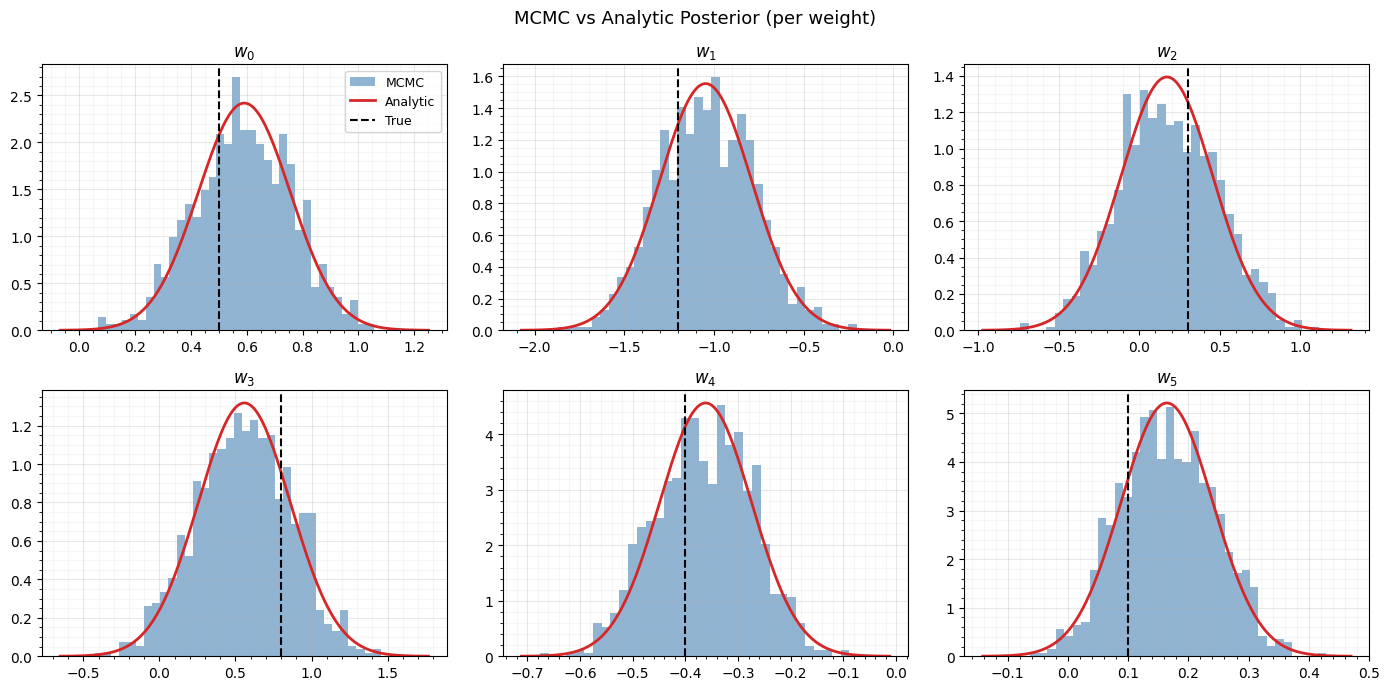

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    # MCMC histogram
    ax.hist(
        w_samples[:, i],
        bins=35,
        density=True,
        alpha=0.6,
        color="steelblue",
        label="MCMC",
    )

    # Analytic posterior
    w_grid = jnp.linspace(
        mu_post[i] - 4 * jnp.sqrt(Sigma_post[i, i]),
        mu_post[i] + 4 * jnp.sqrt(Sigma_post[i, i]),
        200,
    )
    pdf = jnp.exp(dist.Normal(mu_post[i], jnp.sqrt(Sigma_post[i, i])).log_prob(w_grid))
    ax.plot(w_grid, pdf, "C3-", lw=2, label="Analytic")

    # True value
    ax.axvline(w_true[i], color="k", ls="--", lw=1.5, label="True")

    ax.set_title(f"$w_{i}$")
    if i == 0:
        ax.legend(fontsize=9)
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
    ax.minorticks_on()

fig.suptitle("MCMC vs Analytic Posterior (per weight)", fontsize=13)
plt.tight_layout()
plt.show()

## Posterior predictive

We compute the predictive distribution by pushing MCMC weight
samples through the model.

In [8]:
# Predictive mean for each sample
y_pred = w_samples @ X_test.T  # (n_samples, n_test)

pred_mean = jnp.mean(y_pred, axis=0)
# Total predictive std: epistemic (weight uncertainty) + aleatoric (noise)
pred_std = jnp.sqrt(jnp.var(y_pred, axis=0) + noise_std**2)

# Also compute analytic predictive
analytic_mean = X_test @ mu_post
analytic_var = jnp.sum(X_test @ Sigma_post * X_test, axis=1) + noise_std**2
analytic_std = jnp.sqrt(analytic_var)

print(f"MCMC pred mean shape: {pred_mean.shape}")
print(f"Analytic pred mean shape: {analytic_mean.shape}")

MCMC pred mean shape: (200,)
Analytic pred mean shape: (200,)


## Plot predictions

The MCMC posterior predictive should closely match the analytic
solution. Both include observation noise in the uncertainty bands.

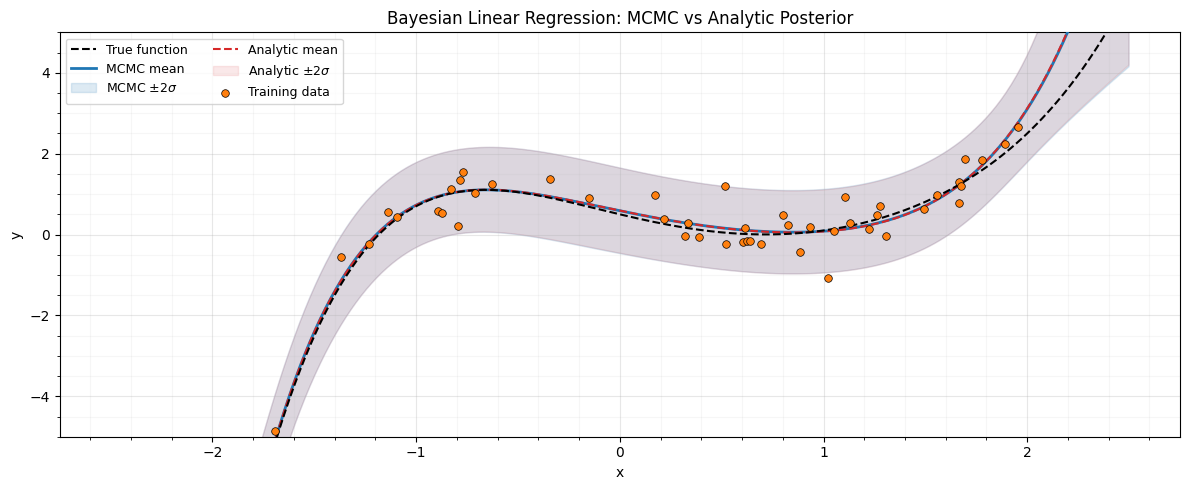

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

# True function
y_true_test = X_test @ w_true
ax.plot(x_test, y_true_test, "k--", lw=1.5, label="True function", zorder=4)

# MCMC predictive
ax.plot(x_test, pred_mean, "C0-", lw=2, label="MCMC mean", zorder=3)
ax.fill_between(
    x_test,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    color="C0",
    alpha=0.15,
    label=r"MCMC $\pm 2\sigma$",
)

# Analytic predictive
ax.plot(x_test, analytic_mean, "C3--", lw=1.5, label="Analytic mean", zorder=3)
ax.fill_between(
    x_test,
    analytic_mean - 2 * analytic_std,
    analytic_mean + 2 * analytic_std,
    color="C3",
    alpha=0.1,
    label=r"Analytic $\pm 2\sigma$",
)

# Training data
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    label="Training data",
    zorder=5,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Bayesian Linear Regression: MCMC vs Analytic Posterior")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.set_ylim(-5, 5)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Precision additivity

The key advantage of precision parameterization: posterior
precision = prior precision + data precision. Let's verify this
with gaussx.

Each observation adds information (in the Fisher sense) to the
posterior. The posterior precision
$\Lambda_{\text{post}} = \Lambda_0 + \Lambda_{\text{data}}$ directly
reflects this: the total information is the sum of prior information
and data information. This additivity is the defining property of the
natural parameters of the exponential family.

In [10]:
# Build operators
Lambda_0_op = lx.MatrixLinearOperator(Lambda_0, lx.positive_semidefinite_tag)
Lambda_data_op = lx.MatrixLinearOperator(Lambda_data, lx.positive_semidefinite_tag)
Lambda_post_op = lx.MatrixLinearOperator(Lambda_post, lx.positive_semidefinite_tag)

# Prior
d_prior = gaussx.MultivariateNormalPrecision(jnp.zeros(d), Lambda_0_op)
print("Prior entropy:", d_prior.entropy())

# Posterior
d_post = gaussx.MultivariateNormalPrecision(mu_post, Lambda_post_op)
print("Posterior entropy:", d_post.entropy())

# Entropy should decrease (more information)
print("Entropy decreased:", float(d_prior.entropy()) > float(d_post.entropy()))

# Verify log-prob at posterior mean
print("log p(mu_post | posterior):", d_post.log_prob(mu_post))

Prior entropy: 8.513631199228037
Posterior entropy: -7.486669349647968
Entropy decreased: True


log p(mu_post | posterior): 10.486669349647968


## Summary

- `gaussx.MultivariateNormalPrecision` naturally encodes ridge
  regularization and conjugate Bayesian updates.
- It plugs directly into NumPyro models — NUTS computes gradients
  through the precision-parameterized log-prob.
- For linear-Gaussian models, the MCMC posterior matches the
  analytic conjugate solution, validating the implementation.
- **Precision additivity** ($\Lambda_{\text{post}} =
  \Lambda_0 + \Lambda_{\text{data}}$) makes sequential updates
  trivial — just add precision operators.
- The same pattern extends to structured precisions (banded,
  Kronecker, block-diagonal) for scalable models like GMRFs.

## References

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*.
  Springer. (Section 3.3 on Bayesian linear regression)
- Lindgren, F., Rue, H., & Lindstrom, J. (2011). An explicit link
  between Gaussian fields and Gaussian Markov random fields: the
  stochastic partial differential equation approach. *JRSS-B*, 73(4),
  423--498.
- Rue, H. & Held, L. (2005). *Gaussian Markov Random Fields: Theory
  and Applications*. Chapman & Hall/CRC.